# Production Monitoring

Имитируем работу модели после deployment.

- `production_1`: первые новые данные после запуска модели;
- сначала считаем, что target ещё неизвестен;
- анализируем входные данные и прогнозы модели;
- позже получаем фактические `is_canceled` и оцениваем качество;
- `production_2` оставляем для последующей проверки новой версии модели.

## Загружаем test

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

test = pd.read_parquet(
    "../data/processed/test.parquet"
)

test["booking_date"] = pd.to_datetime(
    test["booking_date"]
)

test.shape

(18696, 38)

## Делим будущий период

In [2]:
production_1 = test[
    (test["booking_date"] >= "2017-02-01")
    & (test["booking_date"] < "2017-05-01")
].copy()

production_2 = test[
    test["booking_date"] >= "2017-05-01"
].copy()

print("Production 1:", production_1.shape)
print("Production 2:", production_2.shape)

Production 1: (12117, 38)
Production 2: (6579, 38)


То есть:

Feb + Mar + Apr → production_1

May + Jun + Jul + Aug → production_2

## Спрячем target

В реальной системе в момент поступления бронирования мы знаем признаки, но ещё не знаем, отменит клиент бронь или нет

In [4]:
production_1_labels = production_1[
    "is_canceled"
].copy()

production_1_live = production_1.drop(
    columns="is_canceled"
).copy()

print(
    "Видно?",
    "is_canceled" in production_1_live.columns
)

Видно? False


## Посмотрим временной диапозон

In [5]:
summary = pd.DataFrame({
    "dataset": [
        "production_1",
        "production_2",
    ],
    "rows": [
        len(production_1),
        len(production_2),
    ],
    "date_from": [
        production_1["booking_date"].min(),
        production_2["booking_date"].min(),
    ],
    "date_to": [
        production_1["booking_date"].max(),
        production_2["booking_date"].max(),
    ],
})

summary

,dataset,rows,date_from,date_to
0,production_1,12117,2017-02-01,2017-04-30
1,production_2,6579,2017-05-01,2017-08-31


In [7]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.inference import CancellationPredictor

predictor = CancellationPredictor()

In [8]:
production_1_predictions = predictor.predict_batch(
    production_1_live
)

production_1_predictions.head()

,prediction,cancellation_probability,model_version
0,0,0.108161,v1
1,0,0.084764,v1
2,0,0.052418,v1
3,0,0.110267,v1
4,0,0.081106,v1


In [9]:
production_1_predictions.shape

(12117, 3)

## Соберем таблицу, которую условно логировал бы production

In [10]:
production_1_monitoring = (
    production_1_live
    .join(production_1_predictions)
)

production_1_monitoring[
    [
        "booking_date",
        "hotel",
        "lead_time",
        "deposit_type",
        "prediction",
        "cancellation_probability",
        "model_version",
    ]
].head()

,booking_date,hotel,lead_time,deposit_type,prediction,cancellation_probability,model_version
0,2017-02-01,Resort Hotel,0,No Deposit,0,0.108161,v1
1,2017-02-02,Resort Hotel,0,No Deposit,0,0.084764,v1
2,2017-02-02,Resort Hotel,0,No Deposit,0,0.052418,v1
3,2017-02-01,Resort Hotel,2,No Deposit,0,0.110267,v1
4,2017-02-04,Resort Hotel,0,No Deposit,0,0.081106,v1


In [11]:
assert "is_canceled" not in production_1_monitoring.columns

production_1_monitoring.shape

(12117, 40)

## Смотрим поведение модели без labels

In [12]:
prediction_summary = pd.Series({
    "rows": len(production_1_monitoring),

    "mean_probability":
        production_1_monitoring[
            "cancellation_probability"
        ].mean(),

    "median_probability":
        production_1_monitoring[
            "cancellation_probability"
        ].median(),

    "predicted_cancellation_rate":
        production_1_monitoring[
            "prediction"
        ].mean(),

    "p90_probability":
        production_1_monitoring[
            "cancellation_probability"
        ].quantile(0.90),
})

prediction_summary

rows                           12117.000000
mean_probability                   0.374375
median_probability                 0.302302
predicted_cancellation_rate        0.444169
p90_probability                    0.856444
dtype: float64

## Нужен прошлый reference для сравнения

Для мониторинга мало знать, что средняя вероятность, например, 0.25. Нам надо понимать: это нормально для нашей модели или раньше было иначе?

`Возьмём validation как reference-период`

In [13]:
validation = pd.read_parquet(
    "../data/processed/validation.parquet"
)

validation_live = validation.drop(
    columns="is_canceled"
)

validation_predictions = predictor.predict_batch(
    validation_live
)

validation_monitoring = (
    validation_live
    .join(validation_predictions)
)

Сравниваем поведение модели

In [14]:
prediction_comparison = pd.DataFrame({
    "validation": {
        "mean_probability":
            validation_monitoring[
                "cancellation_probability"
            ].mean(),

        "median_probability":
            validation_monitoring[
                "cancellation_probability"
            ].median(),

        "predicted_cancellation_rate":
            validation_monitoring[
                "prediction"
            ].mean(),

        "p90_probability":
            validation_monitoring[
                "cancellation_probability"
            ].quantile(0.90),
    },

    "production_1": {
        "mean_probability":
            production_1_monitoring[
                "cancellation_probability"
            ].mean(),

        "median_probability":
            production_1_monitoring[
                "cancellation_probability"
            ].median(),

        "predicted_cancellation_rate":
            production_1_monitoring[
                "prediction"
            ].mean(),

        "p90_probability":
            production_1_monitoring[
                "cancellation_probability"
            ].quantile(0.90),
    },
})

prediction_comparison.round(4)

,validation,production_1
mean_probability,0.4282,0.3744
median_probability,0.3800,0.3023
predicted_cancellation_rate,0.4984,0.4442
p90_probability,0.9988,0.8564


Распределение прогнозов изменилось относительно reference-периода

## Посмотрим распределение вероятностей

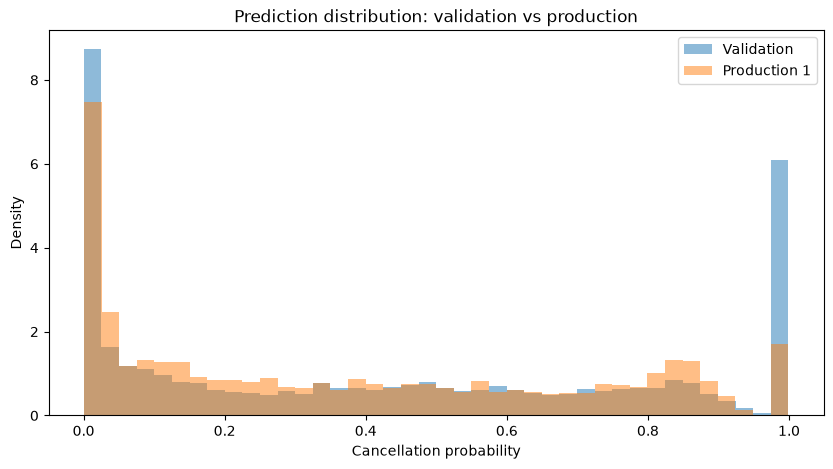

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(
    validation_monitoring["cancellation_probability"],
    bins=40,
    alpha=0.5,
    density=True,
    label="Validation",
)

plt.hist(
    production_1_monitoring["cancellation_probability"],
    bins=40,
    alpha=0.5,
    density=True,
    label="Production 1",
)

plt.xlabel("Cancellation probability")
plt.ylabel("Density")
plt.title("Prediction distribution: validation vs production")
plt.legend()

plt.show()

## Data drift

Сравним распределения входных признаков между validation и production_1.
Target пока не используем.

Гипотеза:

input distribution изменилось -> изменились важные для модели признаки -> изменилось распределение predictions

### Числовые признаки

In [16]:
numeric_features = [
    "lead_time",
    "adr",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "total_of_special_requests",
    "required_car_parking_spaces",
    "total_nights",
    "total_guests",
]

numeric_drift = []

for feature in numeric_features:
    numeric_drift.append({
        "feature": feature,

        "validation_mean":
            validation_monitoring[feature].mean(),

        "production_mean":
            production_1_monitoring[feature].mean(),

        "validation_median":
            validation_monitoring[feature].median(),

        "production_median":
            production_1_monitoring[feature].median(),
    })

numeric_drift = pd.DataFrame(numeric_drift)

numeric_drift.round(3)

,feature,validation_mean,production_mean,validation_median,production_median
0,lead_time,90.810,63.236,77.0,47.0
1,adr,98.425,121.340,93.5,117.0
2,previous_cancellations,0.014,0.008,0.0,0.0
3,previous_bookings_not_canceled,0.177,0.184,0.0,0.0
4,total_of_special_requests,0.600,0.649,0.0,0.0
5,required_car_parking_spaces,0.056,0.071,0.0,0.0
6,total_nights,3.542,3.359,3.0,3.0
7,total_guests,1.960,2.008,2.0,2.0


### Категориальные признаки

In [17]:
def compare_categories(feature, top_n=10):
    validation_share = (
        validation_monitoring[feature]
        .value_counts(normalize=True, dropna=False)
        .rename("validation")
    )

    production_share = (
        production_1_monitoring[feature]
        .value_counts(normalize=True, dropna=False)
        .rename("production_1")
    )

    comparison = pd.concat(
        [
            validation_share,
            production_share,
        ],
        axis=1,
    ).fillna(0)

    comparison["change"] = (
        comparison["production_1"]
        - comparison["validation"]
    )

    comparison["abs_change"] = (
        comparison["change"].abs()
    )

    return (
        comparison
        .sort_values("abs_change", ascending=False)
        .head(top_n)
    )

Разбиарем признаки по важности shap


In [23]:
cat_feat = ["deposit_type", "market_segment", "hotel", "customer_type"]

In [ ]:
for cat in cat_feat:
    display(
    compare_categories(
        cat
    )
    .round(4)
    ) 

,validation,production_1,change,abs_change
deposit_type,,,,
Non Refund,0.1524,0.0426,-0.1099,0.1099
No Deposit,0.8472,0.9567,0.1095,0.1095
Refundable,0.0004,0.0007,0.0004,0.0004


,validation,production_1,change,abs_change
market_segment,,,,
Groups,0.1813,0.0709,-0.1105,0.1105
Online TA,0.5138,0.6063,0.0924,0.0924
Direct,0.1007,0.1504,0.0497,0.0497
Offline TA/TO,0.1498,0.1145,-0.0352,0.0352
Aviation,0.0009,0.0029,0.0020,0.0020
Complementary,0.0055,0.0070,0.0015,0.0015
Corporate,0.0480,0.0480,0.0000,0.0000


,validation,production_1,change,abs_change
hotel,,,,
City Hotel,0.7016,0.6583,-0.0433,0.0433
Resort Hotel,0.2984,0.3417,0.0433,0.0433


,validation,production_1,change,abs_change
customer_type,,,,
Transient-Party,0.1441,0.1101,-0.0341,0.0341
Transient,0.8420,0.8664,0.0244,0.0244
Contract,0.0098,0.0169,0.0071,0.0071
Group,0.0041,0.0066,0.0025,0.0025


###  Вывод

Важные для модели признаки действительно изменились.

Сейчас: `Non Refund `сильно уменьшился -> `lead_time `заметно уменьшился -> Меньше очень рискованных объектов -> Вероятности предсказания сместились вниз

## PSI — формальная оценка drift

Для наиболее важных признаков считаем `Population Stability Index` (PSI), чтобы количественно оценить отличие production от reference-периода.

In [26]:
def calculate_numeric_psi(
    reference,
    current,
    bins=10,
    eps=1e-6,
):
    reference = reference.dropna()
    current = current.dropna()

    edges = np.unique(
        np.quantile(
            reference,
            np.linspace(0, 1, bins + 1)
        )
    )

    if len(edges) < 3:
        return np.nan

    edges[0] = -np.inf
    edges[-1] = np.inf

    reference_counts = np.histogram(
        reference,
        bins=edges
    )[0]

    current_counts = np.histogram(
        current,
        bins=edges
    )[0]

    reference_share = (
        reference_counts / reference_counts.sum()
    )

    current_share = (
        current_counts / current_counts.sum()
    )

    reference_share = np.clip(
        reference_share,
        eps,
        None,
    )

    current_share = np.clip(
        current_share,
        eps,
        None,
    )

    psi = np.sum(
        (current_share - reference_share)
        * np.log(
            current_share / reference_share
        )
    )

    return psi

In [27]:
psi_results = []

for feature in numeric_features:
    psi = calculate_numeric_psi(
        validation_monitoring[feature],
        production_1_monitoring[feature],
    )

    psi_results.append({
        "feature": feature,
        "psi": psi,
    })

psi_results = (
    pd.DataFrame(psi_results)
    .sort_values(
        "psi",
        ascending=False
    )
)

psi_results.round(4)

,feature,psi
0,lead_time,0.4249
1,adr,0.2697
6,total_nights,0.0178
7,total_guests,0.0090
4,total_of_special_requests,0.0053
2,previous_cancellations,NaN
3,previous_bookings_not_canceled,NaN
5,required_car_parking_spaces,NaN


### Категориальные признаки

In [28]:
def calculate_categorical_psi(
    reference,
    current,
    eps=1e-6,
):
    reference_share = (
        reference
        .fillna("Missing")
        .astype(str)
        .value_counts(normalize=True)
    )

    current_share = (
        current
        .fillna("Missing")
        .astype(str)
        .value_counts(normalize=True)
    )

    categories = (
        reference_share.index
        .union(current_share.index)
    )

    reference_share = (
        reference_share
        .reindex(categories, fill_value=0)
        .clip(lower=eps)
    )

    current_share = (
        current_share
        .reindex(categories, fill_value=0)
        .clip(lower=eps)
    )

    return np.sum(
        (current_share - reference_share)
        * np.log(
            current_share / reference_share
        )
    )

In [29]:
categorical_features = [
    "deposit_type",
    "market_segment",
    "country_group",
    "hotel",
    "customer_type",
]

categorical_psi = []

for feature in categorical_features:
    psi = calculate_categorical_psi(
        validation_monitoring[feature],
        production_1_monitoring[feature],
    )

    categorical_psi.append({
        "feature": feature,
        "psi": psi,
    })

categorical_psi = (
    pd.DataFrame(categorical_psi)
    .sort_values(
        "psi",
        ascending=False
    )
)

categorical_psi.round(4)

,feature,psi
0,deposit_type,0.1537
1,market_segment,0.1512
2,country_group,0.0244
4,customer_type,0.0150
3,hotel,0.0086


### Вывод по drift

На `production_1` относительно validation обнаружен заметный сдвиг входных данных.

Самый сильный drift наблюдается у `lead_time` (PSI = 0.425) и `adr` (PSI = 0.270). Также заметно изменились категориальные признаки `deposit_type` (PSI = 0.154) и `market_segment` (PSI = 0.151).

Остальные проверенные признаки изменились значительно слабее.

Это согласуется с prediction drift: в production модель в среднем выдаёт более низкие вероятности отмены. Особенно важным выглядит изменение `lead_time` и резкое снижение доли `Non Refund`, поскольку эти признаки сильно влияют на прогноз модели.

На этом этапе мы видим drift входных данных и прогнозов, но ещё не можем утверждать, что качество модели ухудшилось — для этого нужны фактические значения target.

## Quality monitoring после появления labels

Прошло достаточно времени, чтобы узнать фактический статус бронирований из `production_1`.

Теперь можно проверить, сохранилось ли качество модели после обнаруженного data и prediction drift.

In [30]:
y_prod = production_1_labels

prod_pred = production_1_predictions[
    "prediction"
]

prod_proba = production_1_predictions[
    "cancellation_probability"
]

print("Rows:", len(y_prod))
print("Cancellation rate:", y_prod.mean())

Rows: 12117
Cancellation rate: 0.3259057522489065


### Считаем качество v1 на production_1

In [31]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

In [32]:
production_1_metrics = {
    "precision": precision_score(
        y_prod,
        prod_pred,
        zero_division=0,
    ),
    "recall": recall_score(
        y_prod,
        prod_pred,
        zero_division=0,
    ),
    "f1": f1_score(
        y_prod,
        prod_pred,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_prod,
        prod_proba,
    ),
    "pr_auc": average_precision_score(
        y_prod,
        prod_proba,
    ),
}

pd.Series(
    production_1_metrics
).round(4)

precision    0.6273
recall       0.8549
f1           0.7236
roc_auc      0.8872
pr_auc       0.7862
dtype: float64

### Сравниваем с validation

In [33]:
y_val = validation["is_canceled"]

val_pred = validation_predictions[
    "prediction"
]

val_proba = validation_predictions[
    "cancellation_probability"
]

In [34]:
validation_metrics = {
    "precision": precision_score(
        y_val,
        val_pred,
        zero_division=0,
    ),
    "recall": recall_score(
        y_val,
        val_pred,
        zero_division=0,
    ),
    "f1": f1_score(
        y_val,
        val_pred,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_val,
        val_proba,
    ),
    "pr_auc": average_precision_score(
        y_val,
        val_proba,
    ),
}

### Итоговая таблица

In [35]:
quality_comparison = pd.DataFrame({
    "validation": validation_metrics,
    "production_1": production_1_metrics,
})

quality_comparison["change"] = (
    quality_comparison["production_1"]
    - quality_comparison["validation"]
)

quality_comparison.round(4)

,validation,production_1,change
precision,0.7099,0.6273,-0.0826
recall,0.9008,0.8549,-0.0459
f1,0.7940,0.7236,-0.0704
roc_auc,0.9254,0.8872,-0.0382
pr_auc,0.8985,0.7862,-0.1122


Посмотрим сколько модель реально предсказала как отмену

In [36]:
target_comparison = pd.Series({
    "validation_cancellation_rate":
        y_val.mean(),

    "production_1_cancellation_rate":
        y_prod.mean(),

    "validation_predicted_rate":
        val_pred.mean(),

    "production_1_predicted_rate":
        prod_pred.mean(),
})

target_comparison.round(4)

validation_cancellation_rate      0.3928
production_1_cancellation_rate    0.3259
validation_predicted_rate         0.4984
production_1_predicted_rate       0.4442
dtype: float64

### Вывод 

После появления фактических labels стало видно, что найденный drift действительно привёл к ухудшению качества модели.

На `production_1` снизились все основные метрики: precision, recall, F1, ROC-AUC и PR-AUC. Recall упал с 0.901 до 0.855, поэтому ранее подобранный threshold больше не выполняет целевое условие recall >= 0.90.

Также фактическая доля отмен снизилась с 39.3% на validation до 32.6% на production_1, а модель продолжает предсказывать заметно больше отмен, чем происходит на самом деле.

Это даёт основание для retraining модели на свежих данных.